In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

In [3]:
student_performance = fetch_ucirepo(id=320)

X = student_performance.data.features
y = student_performance.data.targets

df = pd.concat([X, y], axis=1)

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [4]:
df.shape

(649, 33)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

In [6]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [10]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


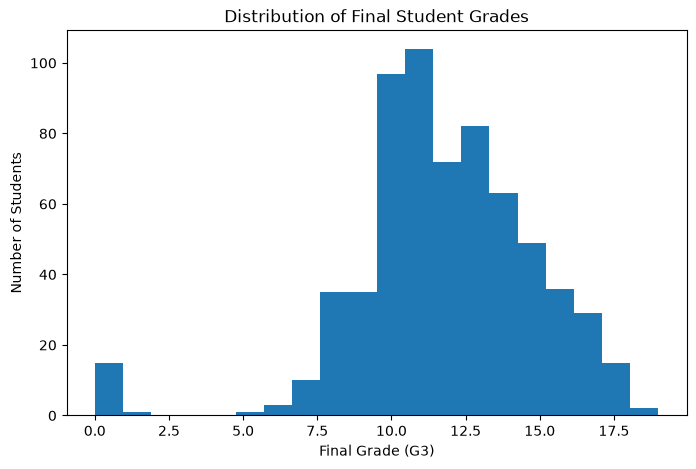

In [11]:
plt.figure(figsize=(8, 5))

plt.hist(df["G3"], bins=20)

plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Student Grades")

plt.show()

In [12]:
print("Average final grade:", df["G3"].mean())
print("Minimum:", df["G3"].min())
print("Maximum:", df["G3"].max())

Average final grade: 11.906009244992296
Minimum: 0
Maximum: 19


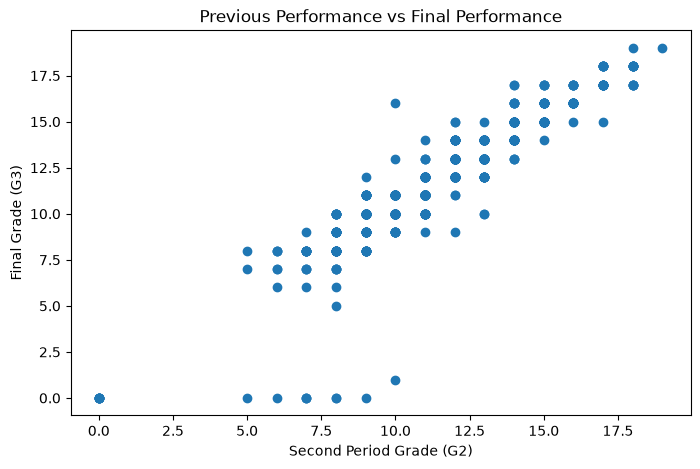

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(df["G2"], df["G3"])

plt.xlabel("Second Period Grade (G2)")
plt.ylabel("Final Grade (G3)")
plt.title("Previous Performance vs Final Performance")

plt.show()

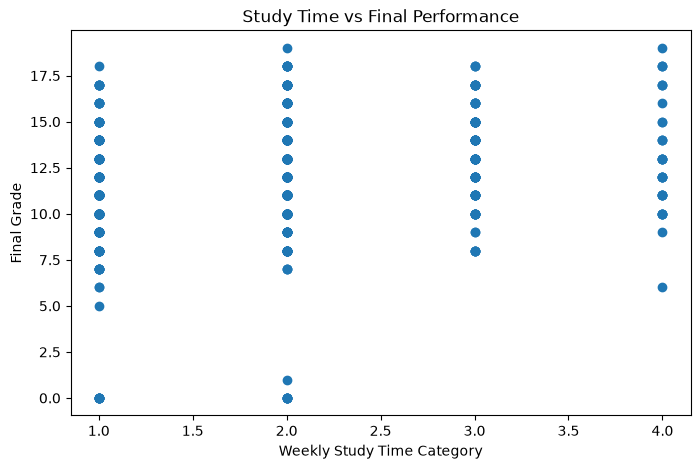

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(df["studytime"], df["G3"])

plt.xlabel("Weekly Study Time Category")
plt.ylabel("Final Grade")
plt.title("Study Time vs Final Performance")

plt.show()

In [15]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

correlations = numeric_df.corr()["G3"].sort_values(
    ascending=False
)

correlations

G3            1.000000
G2            0.918548
G1            0.826387
studytime     0.249789
Medu          0.240151
Fedu          0.211800
famrel        0.063361
goout        -0.087641
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
Walc         -0.176619
Dalc         -0.204719
failures     -0.393316
Name: G3, dtype: float64

In [16]:
correlations

G3            1.000000
G2            0.918548
G1            0.826387
studytime     0.249789
Medu          0.240151
Fedu          0.211800
famrel        0.063361
goout        -0.087641
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
Walc         -0.176619
Dalc         -0.204719
failures     -0.393316
Name: G3, dtype: float64

In [17]:
features = [
    "G1",
    "G2",
    "studytime",
    "failures",
    "absences"
]

X = df[features]
y = df["G3"]

X.head()

,G1,G2,studytime,failures,absences
0,0,11,2,0,4
1,9,11,2,0,2
2,12,13,2,0,6
3,14,14,3,0,0
4,11,13,2,0,0


In [18]:
y.head()

0    11
1    11
2    12
3    14
4    13
Name: G3, dtype: int64

In [19]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (649, 5)
y shape: (649,)


In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 519
Testing samples: 130


In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
linear_model = LinearRegression()

In [24]:
linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0.18, 0.87, 0.11,-0.15, 0.03]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['G1','G2','studytime','failures','absences']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.5183
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [25]:
linear_predictions = linear_model.predict(X_test)

In [26]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [27]:
mae = mean_absolute_error(
    y_test,
    linear_predictions
)

rmse = mean_squared_error(
    y_test,
    linear_predictions
) ** 0.5

r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression")
print("-----------------")
print("MAE :", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²  :", round(r2, 3))

Linear Regression
-----------------
MAE : 0.746
RMSE: 1.155
R²  : 0.863


In [28]:
from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

random_forest.fit(
    X_train,
    y_train
)

rf_predictions = random_forest.predict(
    X_test
)

In [29]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = mean_squared_error(
    y_test,
    rf_predictions
) ** 0.5

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest")
print("-----------------")
print("MAE :", round(rf_mae, 3))
print("RMSE:", round(rf_rmse, 3))
print("R²  :", round(rf_r2, 3))

Random Forest
-----------------
MAE : 0.8
RMSE: 1.329
R²  : 0.819


In [30]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting = GradientBoostingRegressor(
    random_state=42
)

gradient_boosting.fit(
    X_train,
    y_train
)

gb_predictions = gradient_boosting.predict(
    X_test
)

In [31]:
gb_mae = mean_absolute_error(
    y_test,
    gb_predictions
)

gb_rmse = mean_squared_error(
    y_test,
    gb_predictions
) ** 0.5

gb_r2 = r2_score(
    y_test,
    gb_predictions
)

print("Gradient Boosting")
print("-----------------")
print("MAE :", round(gb_mae, 3))
print("RMSE:", round(gb_rmse, 3))
print("R²  :", round(gb_r2, 3))

Gradient Boosting
-----------------
MAE : 0.771
RMSE: 1.343
R²  : 0.815


In [32]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE": [
        mae,
        rf_mae,
        gb_mae
    ],

    "RMSE": [
        rmse,
        rf_rmse,
        gb_rmse
    ],

    "R2": [
        r2,
        rf_r2,
        gb_r2
    ]
})

results.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,RMSE,R2
0,Linear Regression,0.746241,1.154736,0.863264
1,Random Forest,0.800399,1.328893,0.818908
2,Gradient Boosting,0.771003,1.342881,0.815076


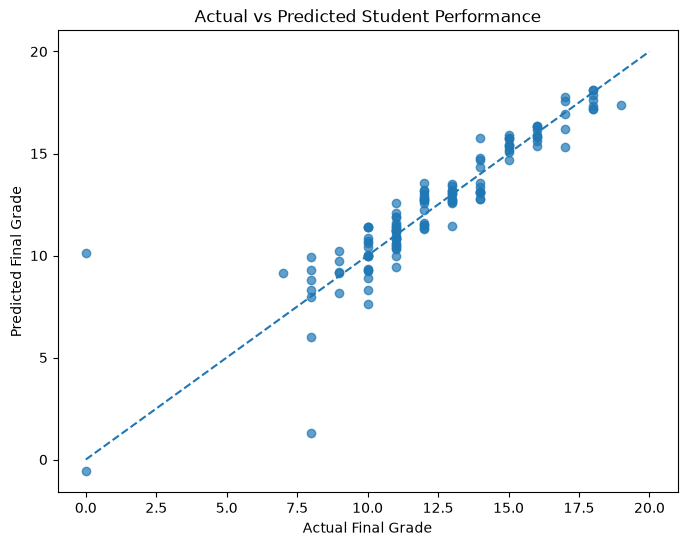

In [33]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    gb_predictions,
    alpha=0.7
)

plt.plot(
    [0, 20],
    [0, 20],
    linestyle="--"
)

plt.xlabel("Actual Final Grade")
plt.ylabel("Predicted Final Grade")
plt.title("Actual vs Predicted Student Performance")

plt.show()

In [34]:
results.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,RMSE,R2
0,Linear Regression,0.746241,1.154736,0.863264
1,Random Forest,0.800399,1.328893,0.818908
2,Gradient Boosting,0.771003,1.342881,0.815076


In [35]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": linear_model.coef_
})

coefficients

,Feature,Coefficient
0,G1,0.181200
1,G2,0.872573
2,studytime,0.114165
3,failures,-0.153936
4,absences,0.025192


In [36]:
print("Intercept:", linear_model.intercept_)

Intercept: -0.5182562454703401


In [37]:
student = pd.DataFrame([{
    "G1": 14,
    "G2": 15,
    "studytime": 3,
    "failures": 0,
    "absences": 4
}])

prediction = linear_model.predict(student)[0]

print("Predicted G3:", round(prediction, 2))
print(
    "Predicted Percentage:",
    round((prediction / 20) * 100, 2),
    "%"
)

Predicted G3: 15.55
Predicted Percentage: 77.75 %


In [38]:
student = pd.DataFrame([{
    "G1": 7,
    "G2": 8,
    "studytime": 1,
    "failures": 2,
    "absences": 15
}])

prediction = linear_model.predict(student)[0]

prediction = max(0, min(20, prediction))

print("Predicted G3:", round(prediction, 2))
print(
    "Predicted Percentage:",
    round((prediction / 20) * 100, 2),
    "%"
)

Predicted G3: 7.91
Predicted Percentage: 39.57 %


In [39]:
import joblib

In [40]:
joblib.dump(
    linear_model,
    "../models/student_score_model.pkl"
)

FileNotFoundError: [Errno 2] No such file or directory: '../models/student_score_model.pkl'

In [42]:
import os

print(os.getcwd())

/home/prathambr_16/StudentAI/ml


In [43]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    linear_model,
    "../models/student_score_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [44]:
os.listdir("../models")

['student_score_model.pkl']

In [45]:
joblib.dump(
    linear_model,
    "../models/student_score_model.pkl"
)

['../models/student_score_model.pkl']